In [1]:
import sys                                                                                                                                                                                                        
sys.path.insert(0, '/home/svu/e1498138/emri_search/work')                                                                                                                                                   
                                                                                                                                                                                                                    
from GWfuncs_noise import GravWaveAnalysis, build_waveform_response                                                                                                                                                 
from loglike_timemax_noise import LogLike                                                                                                                                                                           
import numpy as np                                                                                                                                                                                                        
import cupy as cp

In [2]:
use_gpu=True                                                                                                                                       
T = 8/12        # years                 
dt = 5       # seconds

# Source parameters
m1 = 1e6
m2 = 1e1
a = 0.7
p0 = 7.7
e0 = 0.4
xI0 = 1.0
dist = 6 # 9  # Gpc
qS = np.pi
phiS = 0.
qK =  0.
phiK = 0.
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5                                                                                                                           
                                                                                                                                                                                                                                                                                                                                                    
                                        
waveform_response = build_waveform_response(T=T, dt=dt, use_gpu=use_gpu,tdi_gen=1)                                                                                                    
         

In [3]:
params=[m1,m2,a,p0,e0,xI0,dist,qS,phiS,qK,phiK,Phi_phi0,Phi_theta0,Phi_r0]

In [4]:
# n-indexed mode selection parameters
n_vals = np.arange(-1,6)  # n from -1 to 5
ell = 2  # quadrupole only

In [5]:
gwf = GravWaveAnalysis(T=T, dt=dt, use_gpu=True,tdi_gen=1)

In [6]:
# gwf_1yr = GravWaveAnalysis(T=1, dt=dt, use_gpu=True,tdi_gen=1)

In [7]:


loglike_obj= LogLike(                                                                                                                                                                                                       
    params=params,                                                                                                                                                                                                  
    waveform_response=waveform_response,                                                                                                                                                                            
    gwf=gwf,                                                                                                                                                                                                      
    add_noise=True,
    verbose=True,
    ell=ell,                                                                                                                                                                                                          
    n_vals=n_vals,
    M_mode=None,                                                                                                                                                                                                    
)  

[INFO] Added colored noise with seed=0
Delta_T for mode selection: 4207.7533018060785 seconds
Selected modes (l,m,n): [[(2, 0, -1), (2, 1, -1), (2, 2, -1), (2, -1, -1), (2, -2, -1)], [(2, 0, 0), (2, 1, 0), (2, 2, 0), (2, -1, 0), (2, -2, 0)], [(2, 0, 1), (2, 1, 1), (2, 2, 1), (2, -1, 1), (2, -2, 1)], [(2, 0, 2), (2, 1, 2), (2, 2, 2), (2, -1, 2), (2, -2, 2)], [(2, 0, 3), (2, 1, 3), (2, 2, 3), (2, -1, 3), (2, -2, 3)], [(2, 0, 4), (2, 1, 4), (2, 2, 4), (2, -1, 4), (2, -2, 4)], [(2, 0, 5), (2, 1, 5), (2, 2, 5), (2, -1, 5), (2, -2, 5)]]
Selected modes: [[(2, 0, -1), (2, 1, -1), (2, 2, -1), (2, -1, -1), (2, -2, -1)], [(2, 0, 0), (2, 1, 0), (2, 2, 0), (2, -1, 0), (2, -2, 0)], [(2, 0, 1), (2, 1, 1), (2, 2, 1), (2, -1, 1), (2, -2, 1)], [(2, 0, 2), (2, 1, 2), (2, 2, 2), (2, -1, 2), (2, -2, 2)], [(2, 0, 3), (2, 1, 3), (2, 2, 3), (2, -1, 3), (2, -2, 3)], [(2, 0, 4), (2, 1, 4), (2, 2, 4), (2, -1, 4), (2, -2, 4)], [(2, 0, 5), (2, 1, 5), (2, 2, 5), (2, -1, 5), (2, -2, 5)]]
Flattened modes: [(2, 0, -1)

In [8]:
loglike_obj.signal

array([[-2.06200021e-20,  2.30550079e-20, -2.33284528e-20, ...,
         1.56990349e-21,  4.57932513e-22,  1.10159692e-20],
       [ 2.85775387e-20, -1.01369421e-20,  8.01540202e-21, ...,
        -3.18760074e-20,  2.07734575e-20, -3.14389427e-20],
       [ 6.51485032e-21,  2.50626576e-21, -4.81695797e-21, ...,
        -1.50289263e-20,  4.49298602e-21, -1.11553914e-20]])

In [9]:
%%time
#loglike at true param
logl_true=loglike_obj(params)
print(logl_true)

Waveform amplitudes (time-maximized):
  Mode 0: <hf|hf>_timemax=17.8, rho=4.219
  Mode 1: <hf|hf>_timemax=60.24, rho=7.762
  Mode 2: <hf|hf>_timemax=208, rho=14.42
  Mode 3: <hf|hf>_timemax=154, rho=12.41
  Mode 4: <hf|hf>_timemax=62.77, rho=7.923
  Mode 5: <hf|hf>_timemax=18.84, rho=4.34
  Mode 6: <hf|hf>_timemax=4.726, rho=2.174
rho_m: [ 4.21932445  7.76169848 14.42095296 12.41112903  7.92268406  4.34028319
  2.17390524]
Dominant mode index: 2, rho: 14.42
beta=0.01375, rho_dom_M=14.42, rho_tot=24.42
X_scalar (time-maximized): 24.71
Time-maximized Log-likelihood: 23.96
23.960006441958644
CPU times: user 333 ms, sys: 24 ms, total: 357 ms
Wall time: 478 ms


In [10]:
params_perturbed = list(params)                                                                                                                                                                                     
params_perturbed[0] *= 1.01                                                                                                                                                                                         
logl_perturbed = loglike_obj(params_perturbed)                                                                                                                                                                               
print(logl_perturbed)

Waveform amplitudes (time-maximized):
  Mode 0: <hf|hf>_timemax=16.58, rho=4.071
  Mode 1: <hf|hf>_timemax=56.06, rho=7.487
  Mode 2: <hf|hf>_timemax=200.4, rho=14.16
  Mode 3: <hf|hf>_timemax=151.7, rho=12.32
  Mode 4: <hf|hf>_timemax=62.67, rho=7.917
  Mode 5: <hf|hf>_timemax=18.98, rho=4.357
  Mode 6: <hf|hf>_timemax=4.792, rho=2.189
rho_m: [ 4.07136366  7.48729721 14.15580738 12.31527552  7.91662643  4.35666059
  2.18905446]
Dominant mode index: 2, rho: 14.16
beta=0.014, rho_dom_M=14.16, rho_tot=24.06
X_scalar (time-maximized): 5.81
Time-maximized Log-likelihood: 0.929966
0.9299664024549965


In [11]:

def logden_tm(params):
    logm1, logm2, a, p0, e0 = params
    return float(loglike_obj(np.array([10**logm1, 10**logm2, a, p0, e0,
                                    xI0, dist, qS, phiS, qK, phiK,
                                    Phi_phi0, Phi_theta0, Phi_r0])))

In [12]:
param_true = np.array([np.log10(m1), np.log10(m2), a, p0, e0])


In [13]:
# Sanity check at true params
print(logden_tm(param_true))

Waveform amplitudes (time-maximized):
  Mode 0: <hf|hf>_timemax=17.8, rho=4.219
  Mode 1: <hf|hf>_timemax=60.24, rho=7.762
  Mode 2: <hf|hf>_timemax=208, rho=14.42
  Mode 3: <hf|hf>_timemax=154, rho=12.41
  Mode 4: <hf|hf>_timemax=62.77, rho=7.923
  Mode 5: <hf|hf>_timemax=18.84, rho=4.34
  Mode 6: <hf|hf>_timemax=4.726, rho=2.174
rho_m: [ 4.21932445  7.76169848 14.42095296 12.41112903  7.92268406  4.34028319
  2.17390524]
Dominant mode index: 2, rho: 14.42
beta=0.01375, rho_dom_M=14.42, rho_tot=24.42
X_scalar (time-maximized): 24.71
Time-maximized Log-likelihood: 23.96
23.960006441958644


In [162]:
# # Sweep over logm2
# param_idx = 1  # logm2
# # param_secondary = np.array([6.29332246, 0.97236086, 0.3347499, 10.18644061, 0.34722833])

# param_range = np.sort(np.append(np.linspace(0.99, 1.01, 200), param_true[param_idx]))

# f_stats_tm   = np.zeros(len(param_range))
# # f_stats_pm   = np.zeros(len(param_range))
# # f_stats_pure = np.zeros(len(param_range))
# # f_stats_tmX = np.zeros(len(param_range))
# # X_pure = np.zeros(len(param_range))
# X_tm = np.zeros(len(param_range))
# X_tpm = np.zeros(len(param_range))
# X_sc = np.zeros(len(param_range))


# for i, val in enumerate(param_range):

#     p = param_true.copy()
#     p[param_idx] = val
#     # f_stats_tm[i]   = logden_tm(p)
#     # f_stats_pm[i]   = logden_pm(p)
#     # f_stats_pure[i] = logden_pure(p)
#     # f_stats_tmX[i] = logden_tmX(p)

#     # X only (no chi_sq)
#     logm1, logm2, a_i, p0_i, e0_i = p
#     h = gwf.xp.array(waveform_response(
#         10**logm1, 10**logm2, a_i, p0_i, e0_i,
#         xI0, dist, qS, phiS, qK, phiK,
#         Phi_phi0, Phi_theta0, Phi_r0, T=T, dt=dt,
#     ))
#     h_fft_r = gwf.freq_wave(h)
#     rho_h   = float(gwf.xp.sqrt(gwf.inner(h_fft_r, h_fft_r)))
#     # X_pure[i] = float(gwf.inner(loglike_obj.signal_fft, h_fft_r, return_complex=False)) / rho_h
#     # X_tm[i] = float(gwf.inner_timemax(loglike_obj.signal, h,phasemax=False)) / rho_h
#     # X_tpm[i] = float(gwf.inner_timemax(loglike_obj.signal, h,phasemax=True)) / rho_h
#     X_sc[i] = float(gwf.SNR_semicoherent(loglike_obj.signal, h, N_seg=12))

In [14]:
print('Initializing loglike_pure...')
params_star = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]

import loglike_pure_noise
loglike_p = loglike_pure_noise.LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=True,
    verbose=False,
    ell=ell, n_vals=n_vals, M_mode=None,
)

Initializing loglike_pure...


In [15]:
def logden_pure(params):
    logm1, logm2, a, p0, e0 = params
    return float(loglike_p(np.array([10**logm1, 10**logm2, a, p0, e0,
                                    xI0, dist, qS, phiS, qK, phiK,
                                    Phi_phi0, Phi_theta0, Phi_r0])))

In [18]:
# Sweep over logm2
param_idx = 1  # logm2
# param_secondary = np.array([6.29332246, 0.97236086, 0.3347499, 10.18644061, 0.34722833])

param_range = np.sort(np.append(np.linspace(0.975, 1.025, 100), param_true[param_idx]))

f_stats_tm   = np.zeros(len(param_range))
# f_stats_pm   = np.zeros(len(param_range))
f_stats_pure = np.zeros(len(param_range))
# f_stats_tmX = np.zeros(len(param_range))
# X_pure = np.zeros(len(param_range))
X_tm = np.zeros(len(param_range))
X_tpm = np.zeros(len(param_range))
Sthree = np.zeros(len(param_range))
Ssix = np.zeros(len(param_range))
Snine = np.zeros(len(param_range))
Stwelve = np.zeros(len(param_range))
# Ssixteen = np.zeros(len(param_range))
Sp= np.zeros(len(param_range))

for i, val in enumerate(param_range):

    p = param_true.copy()
    p[param_idx] = val
    f_stats_tm[i]   = logden_tm(p)
    # f_stats_pm[i]   = logden_pm(p)
    # f_stats_pure[i] = logden_pure(p)
    # f_stats_tmX[i] = logden_tmX(p)

    # X only (no chi_sq)
    logm1, logm2, a_i, p0_i, e0_i = p
    h = gwf.xp.array(waveform_response(
        10**logm1, 10**logm2, a_i, p0_i, e0_i,
        xI0, dist, qS, phiS, qK, phiK,
        Phi_phi0, Phi_theta0, Phi_r0, T=T, dt=dt,
    ))
    h_fft_r = gwf.freq_wave(h)
    rho_h   = float(gwf.xp.sqrt(gwf.inner(h_fft_r, h_fft_r)))
    # X_pure[i] = float(gwf.inner(loglike_obj.signal_fft, h_fft_r, return_complex=False)) / rho_h
    # X_tm[i] = float(gwf.inner_timemax(loglike_obj.signal, h)) / rho_h
    # X_tpm[i] = float(gwf.inner_timemax(loglike_obj.signal, h)) / rho_h
    Sthree[i] = float(gwf.SNR_semicoherent(loglike_obj.signal, h, N_seg=3))
    Ssix[i] = float(gwf.SNR_semicoherent(loglike_obj.signal, h, N_seg=6))
    Snine[i] = float(gwf.SNR_semicoherent(loglike_obj.signal, h, N_seg=9))
    Stwelve[i] = float(gwf.SNR_semicoherent(loglike_obj.signal, h, N_seg=12))
    # Ssixteen[i] = float(gwf.SNR_semicoherent(loglike_obj.signal, h, N_seg=16))
    # Sp[i] = float(gwf.SNR_semicoherent_nomax(loglike_obj.signal, h, N_seg=12))


Waveform amplitudes (time-maximized):
  Mode 0: <hf|hf>_timemax=14.43, rho=3.798
  Mode 1: <hf|hf>_timemax=47.48, rho=6.89
  Mode 2: <hf|hf>_timemax=176.3, rho=13.28
  Mode 3: <hf|hf>_timemax=136.1, rho=11.67
  Mode 4: <hf|hf>_timemax=56.94, rho=7.546
  Mode 5: <hf|hf>_timemax=17.37, rho=4.167
  Mode 6: <hf|hf>_timemax=4.406, rho=2.099
rho_m: [ 3.79802775  6.89029448 13.2796834  11.66571572  7.54566523  4.16730881
  2.09894412]
Dominant mode index: 2, rho: 13.28
beta=0.01537, rho_dom_M=13.28, rho_tot=22.65
X_scalar (time-maximized): 6.017
Time-maximized Log-likelihood: 1.20548
Waveform amplitudes (time-maximized):
  Mode 0: <hf|hf>_timemax=14.48, rho=3.806
  Mode 1: <hf|hf>_timemax=47.7, rho=6.906
  Mode 2: <hf|hf>_timemax=176.9, rho=13.3
  Mode 3: <hf|hf>_timemax=136.4, rho=11.68
  Mode 4: <hf|hf>_timemax=57.07, rho=7.555
  Mode 5: <hf|hf>_timemax=17.39, rho=4.17
  Mode 6: <hf|hf>_timemax=4.417, rho=2.102
rho_m: [ 3.80587397  6.90637747 13.30209014 11.6805581   7.55466952  4.17019169


In [19]:
import matplotlib.pyplot as plt

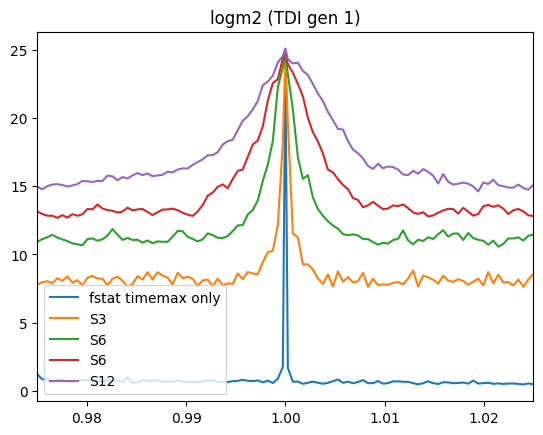

In [20]:
plt.plot(param_range, f_stats_tm,   label='fstat timemax only')
# plt.plot(param_range, f_stats_pm,   label='fstat phasemax only')
# plt.plot(param_range, f_stats_pure, label='fstat pure')
# plt.plot(param_range, f_stats_tmX, label='fstat timemax in X only')
# plt.plot(param_range, X_pure, label='X pure')
# plt.plot(param_range, X_tm, label='X timemax')
# plt.plot(param_range, X_tpm, label='X timemax +phasemax')
plt.plot(param_range, Sthree, label='S3')
plt.plot(param_range, Ssix, label='S6')
plt.plot(param_range, Snine, label='S6')
plt.plot(param_range, Stwelve, label='S12')
# plt.plot(param_range, Ssixteen, label='S16')
# plt.plot(param_range, Sp, label='S12 no timemax')

plt.xlim(0.975, 1.025)
plt.title('logm2 (TDI gen 1)')
plt.legend(loc='lower left')
plt.savefig('logden.png', dpi=300, bbox_inches='tight')
plt.show()

In [56]:
# import matplotlib.pyplot as plt
# fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
# labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$', r'$T$']
# plt.ylabel('logden', fontsize=12)
# for dim in range(5):
#     ax = axs_1d[dim]

#     # Plot theoretical log-density
#     ax.plot(line_points_proc1[dim], X_sc_line, '-', 
#             color='blue', alpha=0.5, linewidth=2, label='semicoherent')


#     # Mark the max likelihood points
#     ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
#                alpha=0.5, label=f'Proc1 Max Logden Point')
#     ax.axvline(param_true[dim], color='red', linestyle='--', 
#                alpha=0.5, label='True Point')
    
#     ax.set_xlabel(labels[dim], fontsize=12)
#     # ax.set_ylabel('logden', fontsize=12)
#     ax.grid(True, alpha=0.3)

# plt.legend()
# plt.tight_layout()


In [57]:
# Generate trajectory to get fundamental frequencies
print("Computing fundamental frequencies...")
from few.trajectory.inspiral import EMRIInspiral
from few.utils.constants import YRSID_SI

N_traj = 5000
delta_T = T*YRSID_SI/5000
traj_gen = EMRIInspiral(func='KerrEccEqFlux')
t_arr, p_arr, e_arr, x_arr, Phi_phi_arr, Phi_theta_arr, Phi_r_arr = traj_gen(
    m1, m2, a, p0, e0, xI0, T=T, dt=dt, upsample=True,
    Phi_phi0=Phi_phi0, Phi_theta0=Phi_theta0, Phi_r0=Phi_r0
)

Computing fundamental frequencies...


In [77]:
from few.utils.utility import get_p_at_t

get_p_at_t(traj_module=traj_gen, t_out=1, traj_args=[m1, m2, a, e0, xI0])


7.688179003044686